# Zendo 交互式游戏测试平台 - Average Confidence Strategy

这个 Notebook 是在 `visualization.ipynb` 的基础上，针对假设生成与检验策略进行了升级：
1. **聚合假设 (Average Confidence)**：不再从 DPP 中选出三个互相独立的假设用于记录，而是选出 10 条链求均值，得到 `[-1, 1]` 之间的“信心水平”（Confidence Level）。
2. **概率衰退与转化**：根据信心分布投掷随机数，将连续的信心水平转化为 `+1` 或 `-1` 的单一决策（模拟直觉模糊但最终需拍板的机制）。
3. **新的主动学习策略**：依靠该信心水平选取“最不确定（信心分最接近0）”且靠近锚点的公案进行下一步检验。

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 导入游戏核心模块
from game import RuleEngine
from world import KoanAtlas
from physics import IsingModel
from dynamics import FastSolver, DPP, SlowLearner
from config import Config

# --- 配置区域 ---
GAME_ID = 6  # <--- 在这里修改你想运行的游戏编号 (1-9)
Config.NUM_HYPOTHESES_KEPT = 10  # 使用 DPP 挑出 10 条链

# 【动力学温度控制开关】
Config.USE_ANNEALING = True      # True: 使用退火机制; False: 使用恒温机制
Config.MCMC_TEMP = 1.0           # 恒温模式下的固定温度 (建议设定在临近点 Tc 约 1.0)
Config.MCMC_END_TEMP = 0.5       # 退火模式下的最低温度 (提高底温防止"纯铁磁相"全局僵死)
# ----------------

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f"✅ 已导入所有模块，准备运行 Game {GAME_ID} (Average Strategy)")

✅ 已导入所有模块，准备运行 Game 6 (Average Strategy)


In [ ]:
from numba import jit

# --- 可复现性设置 ---
SEED = 42  # 你可以修改为你喜欢的任意整数

# 1. 设置 NumPy 全局种子
# 作用范围：Python 层面的逻辑，如初始自旋生成、DPP 采样、规则选择等
np.random.seed(SEED)

# 2. 设置 Numba 内部种子
# 作用范围：被 @jit(nopython=True) 加速的 FastSolver 动力学演化过程
@jit(nopython=True)
def set_numba_seed(value):
    np.random.seed(value)

set_numba_seed(SEED)
print(f"🔒 随机种子已固定为: {SEED} (NumPy & Numba)")
# ------------------

In [2]:
# 初始化游戏系统
print("正在初始化游戏系统...")

atlas = KoanAtlas()
rule_engine = RuleEngine(atlas)
physics = IsingModel(atlas.num_koans)
solver = FastSolver()
dpp = DPP()
learner = SlowLearner(atlas)

print(f"✅ 系统初始化完成")
print(f"   - 公案总数: {atlas.num_koans}")
print(f"   - 可选规则: {len(rule_engine.rules)} 个")

正在初始化游戏系统...
正在初始化 Zendo 公案图册 (Koan Atlas)...
图册构建完成。已索引 5127 个公案。
特征张量形状: (5127, 3, 7)
结构张量形状: (5127, 3, 3)
质量张量形状: (5127, 3)
正在加载距离张量: data/dist_fused_5127.npy ...
距离张量已加载。Shape: (5127, 5127, 4)
✅ 系统初始化完成
   - 公案总数: 5127
   - 可选规则: 9 个


In [3]:
# ========================================
# 运行单局游戏（信心聚合版本）
# ========================================

# 获取 Ground Truth
gt_vector, rule_name = rule_engine.get_ground_truth_vector(GAME_ID - 1)
print(f"\n{'='*60}")
print(f"🎮 开始游戏: {rule_name} (Game {GAME_ID})")
print(f"{'='*60}\n")

# 游戏状态初始化
current_attention = Config.INIT_ATTENTION.copy()
attention_history = [current_attention.copy()]

# 储存每轮的信心水平和生成的决策
rounds_data = []  
round_labels = []
game_log = []

# 初始正例
pos_indices = np.where(gt_vector > 0)[0]
neg_indices = np.where(gt_vector < 0)[0]
known_pos = [np.random.choice(pos_indices)]
known_neg = []

print(f"🚩 初始提示 (正例): 公案 #{known_pos[0]}\n")

# ========================================
# 游戏主循环 (7轮检验)
# ========================================
mcmc_steps = atlas.num_koans * 20 

for round_num in range(7):
    print(f"{'─'*60}")
    print(f"🔄 Round {round_num + 1}/7")
    print(f"{'─'*60}")
    
    # A. 更新物理环境
    dist_matrix = atlas.get_weighted_distance_matrix(current_attention)
    physics.update_couplings(dist_matrix)
    physics.set_pinning_field(known_pos, known_neg, round_num)
    
    # B. 快动力学：生成假设
    print(f"   ⚡ 正在生成 {Config.NUM_CHAINS} 条候选假设 (带退火机制)...")
    chains = []
    
    for _ in range(Config.NUM_CHAINS):
        init_spins = np.random.choice([-1.0, 1.0], size=atlas.num_koans)
        final_spins = solver.run_glauber(physics, init_spins, steps=mcmc_steps)
        chains.append(final_spins)
    
    # C. DPP 选择 10 条链 (由于可能需要计算10x10行列式，耗时约1-2秒)
    print(f"   🔍 正在使用 DPP 挑选最具代表性的 10 条链...")
    selected_indices, det_value = dpp.select_subset(chains, physics)
    current_hypotheses = [chains[i] for i in selected_indices]
    
    # 补全到10个
    while len(current_hypotheses) < 10:
        current_hypotheses.append(chains[np.random.randint(len(chains))])
    
    hyp_stack = np.stack(current_hypotheses)  # (10, N)
    
    # 【核心修改 1】: 将这 10 条链的对应位置求和再除以 10，得到信心水平
    confidence_hypothesis = np.mean(hyp_stack, axis=0) # (N,) array in [-1, 1]
    
    # 【核心修改 2】: 通过生成 [-1, 1] 的随机数进行决策转化
    rand_vals = np.random.uniform(-1, 1, size=atlas.num_koans)
    decision = np.where(rand_vals <= confidence_hypothesis, 1.0, -1.0)
    
    rounds_data.append({
        "confidence": confidence_hypothesis,
        "decision": decision
    })
    round_labels.append(f"R{round_num + 1}")
    
    # D. 计算并输出准确率
    accuracy = np.mean(decision == gt_vector)
    magnetization = np.mean(decision)
    print(f"   📊 本轮概率决策表现:")
    print(f"      - 准确率 (Accuracy): {accuracy*100:.2f}%")
    print(f"      - 磁化强度 (Magnetization): {magnetization:.3f}")
    
    # E. 主动学习: 基于不确定性 + 局部相关性进行检验
    if len(known_pos) > 0:
        anchor_idx = known_pos[-1]
    else:
        anchor_idx = 0
        
    att_logits = current_attention
    exp_logits = np.exp(att_logits - np.max(att_logits))
    att_probs = exp_logits / np.sum(exp_logits)
    f_target = np.random.choice(4, p=att_probs)
    
    known_set = set(known_pos) | set(known_neg)
    unknown_mask = np.ones(atlas.num_koans, dtype=bool)
    unknown_mask[list(known_set)] = False
    
    # 【核心修改 3】: 使用不确定性代替方差
    # 信心越接近 0，说明模型越不确定，不确定性分越高
    uncertainty_score = 1.0 - np.abs(confidence_hypothesis)
    
    dist_vecs = atlas.dist_basis[:, anchor_idx, :] # (N, 4)
    LAMBDA_CONTROL = 100.0
    betas = np.full(4, LAMBDA_CONTROL)
    betas[f_target] = 1.0
    c_local = np.sum(dist_vecs * betas, axis=1) # (N,)
    
    has_change_mask = dist_vecs[:, f_target] > 1e-3
    
    # 综合评分：倾向于不确定性高的，且距离当前锚点小的
    LAMBDA_BALANCE = 2.0
    total_scores = uncertainty_score - LAMBDA_BALANCE * c_local
    
    final_mask = unknown_mask & has_change_mask
    if not np.any(final_mask):
        final_mask = unknown_mask
        total_scores = uncertainty_score
        
    total_scores[~final_mask] = -np.inf
    best_test_idx = np.argmax(total_scores)
    
    feat_names = ["Color", "Size", "Ground", "Touch"]
    print(f"      🎯 策略: 寻找对公案 #{anchor_idx} [{feat_names[f_target]}] 方向上最具不确定性的目标...")
    
    # F. Ground Truth 检验
    truth = gt_vector[best_test_idx]
    is_pos = (truth > 0)
    
    if is_pos:
        known_pos.append(best_test_idx)
        result_str = "✅ Pass"
    else:
        known_neg.append(best_test_idx)
        result_str = "❌ Fail"
    
    print(f"   🧪 检验公案: #{best_test_idx} -> {result_str}")
    
    game_log.append({
        'round': round_num + 1,
        'test_koan': best_test_idx,
        'result': 'Pass' if is_pos else 'Fail',
        'accuracy': accuracy,
        'uncertainty': np.mean(uncertainty_score),
    })
    
    # G. 慢动力学更新
    current_attention = learner.update_attention(current_attention, known_pos, known_neg)
    attention_history.append(current_attention.copy())
    print()

# ========================================
# 最终轮次 (Round Final)
# ========================================
print(f"{'='*60}")
print(f"⚡ 执行最终动力学演化...")
print(f"{'='*60}")

dist_matrix = atlas.get_weighted_distance_matrix(current_attention)
physics.update_couplings(dist_matrix)
physics.set_pinning_field(known_pos, known_neg, round_num=7)

chains = []
for _ in range(Config.NUM_CHAINS):
    init_spins = np.random.choice([-1.0, 1.0], size=atlas.num_koans)
    final_spins = solver.run_glauber(physics, init_spins, steps=mcmc_steps)
    chains.append(final_spins)

selected_indices, _ = dpp.select_subset(chains, physics)
final_hypotheses = [chains[i] for i in selected_indices]
while len(final_hypotheses) < 10:
    final_hypotheses.append(chains[np.random.randint(len(chains))])
    
final_stack = np.stack(final_hypotheses)
final_confidence = np.mean(final_stack, axis=0)

rand_vals = np.random.uniform(-1, 1, size=atlas.num_koans)
final_decision = np.where(rand_vals <= final_confidence, 1.0, -1.0)

rounds_data.append({
    "confidence": final_confidence,
    "decision": final_decision
})
round_labels.append("Final")
attention_history.append(current_attention.copy())

ultimate_acc = np.mean(final_decision == gt_vector)
print(f"   🎯 终极概率验证假设准确率: {ultimate_acc*100:.2f}%")
print(f"   🧲 终极假设平均磁化强度: {np.mean(final_decision):.3f}")
print(f"\n{'='*60}")
print(f"✅ 游戏结束")
print(f"{'='*60}\n")


📜 正在编译规则 [6/9]: 红者最大 ...

🎮 开始游戏: 红者最大 (Game 6)

🚩 初始提示 (正例): 公案 #3378

────────────────────────────────────────────────────────────
🔄 Round 1/7
────────────────────────────────────────────────────────────
   ⚡ 正在生成 20 条候选假设 (带退火机制)...
   🔍 正在使用 DPP 挑选最具代表性的 10 条链...
   📊 本轮概率决策表现:
      - 准确率 (Accuracy): 52.35%
      - 磁化强度 (Magnetization): -0.068
      🎯 策略: 寻找对公案 #3378 [Touch] 方向上最具不确定性的目标...
   🧪 检验公案: #3377 -> ✅ Pass

────────────────────────────────────────────────────────────
🔄 Round 2/7
────────────────────────────────────────────────────────────
   ⚡ 正在生成 20 条候选假设 (带退火机制)...
   🔍 正在使用 DPP 挑选最具代表性的 10 条链...
   📊 本轮概率决策表现:
      - 准确率 (Accuracy): 42.03%
      - 磁化强度 (Magnetization): 0.304
      🎯 策略: 寻找对公案 #3377 [Color] 方向上最具不确定性的目标...
   🧪 检验公案: #3280 -> ❌ Fail

────────────────────────────────────────────────────────────
🔄 Round 3/7
────────────────────────────────────────────────────────────
   ⚡ 正在生成 20 条候选假设 (带退火机制)...
   🔍 正在使用 DPP 挑选最具代表性的 10 条链...
   📊 本轮概率决策表现:
      -

📈 统计分析完成，开始绘图...



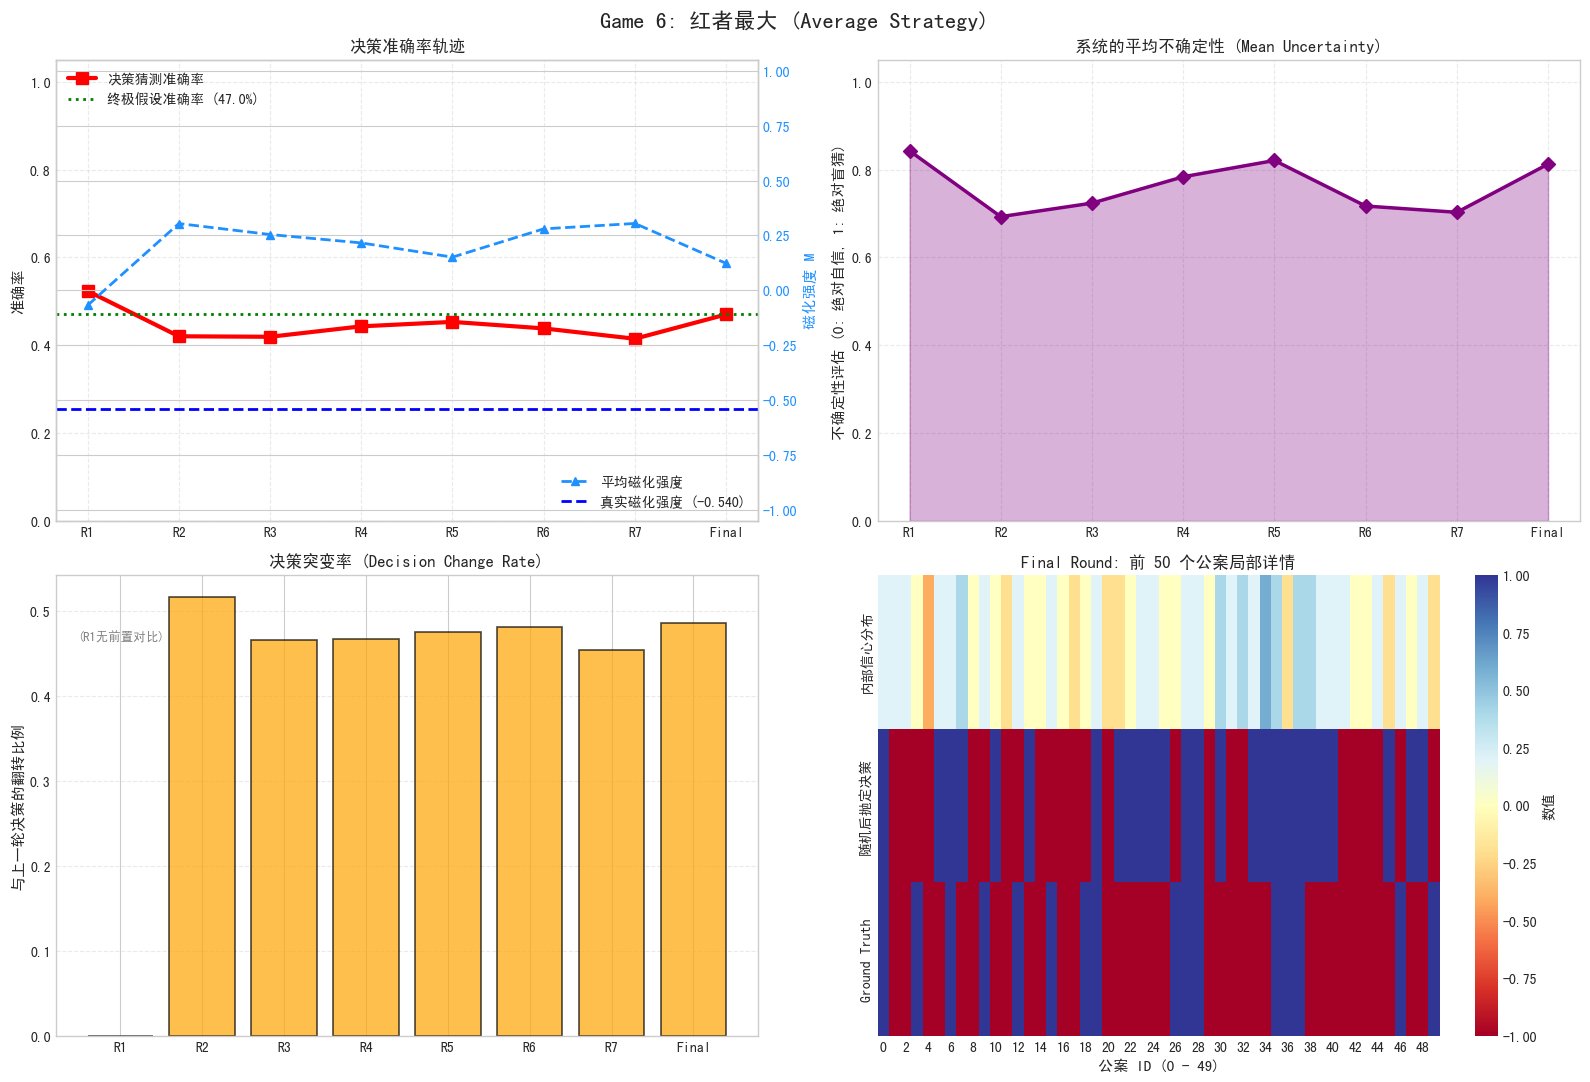

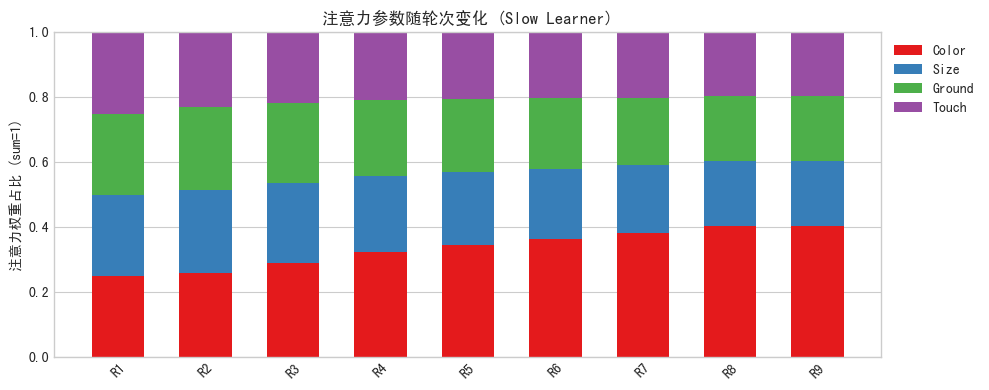

In [4]:
# ========================================
# 数据分析与混合可视化
# ========================================

stats = {
    "accuracies": [],
    "magnetization": [],
    "uncertainty": [],
    "stability": [],
    "ultimate_acc": ultimate_acc
}

prev_decision = None

for idx, r_data in enumerate(rounds_data):
    decision = r_data["decision"]
    conf = r_data["confidence"]
    
    # 准确率
    acc = np.mean(decision == gt_vector)
    stats["accuracies"].append(acc)
    
    # 磁化强度
    mag = np.mean(decision)
    stats["magnetization"].append(mag)
    
    # 聚合不确定度 (1 - |confidence|)
    uncert = np.mean(1.0 - np.abs(conf))
    stats["uncertainty"].append(uncert)
    
    # 稳定性（与前一次决策的区别比率，0 代表完全没变，1 代表全变）
    if prev_decision is not None:
        change_rate = np.mean(decision != prev_decision)
        stats["stability"].append(change_rate)
    else:
        stats["stability"].append(0.0)
        
    prev_decision = decision

print("📈 统计分析完成，开始绘图...\n")

# ========================================
# 绘制分析图表
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f"Game {GAME_ID}: {rule_name} (Average Strategy)", fontsize=16, fontweight='bold')

rounds_idx = range(len(round_labels))

# 1. 准确率与磁化强度演变
ax1 = axes[0, 0]
ax1.plot(rounds_idx, stats["accuracies"], color='red', linewidth=3, 
         marker='s', markersize=8, label='决策猜测准确率')
ax1.axhline(y=stats["ultimate_acc"], color='green', linestyle=':', 
            linewidth=2, label=f'终极假设准确率 ({stats["ultimate_acc"]*100:.1f}%)')
ax1.set_xticks(rounds_idx)
ax1.set_xticklabels(round_labels)
ax1.set_ylabel("准确率", fontsize=11)
ax1.set_title("决策准确率轨迹", fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper left')

ax1_t = ax1.twinx()
ax1_t.plot(rounds_idx, stats["magnetization"], color='dodgerblue', linestyle='--',
           linewidth=2, marker='^', label='平均磁化强度')
gt_mag = np.mean(gt_vector)
ax1_t.axhline(y=gt_mag, color='blue', linestyle='--', 
              linewidth=2, label=f'真实磁化强度 ({gt_mag:.3f})')
ax1_t.set_ylabel("磁化强度 M", fontsize=11, color='dodgerblue')
ax1_t.set_ylim(-1.05, 1.05)
ax1_t.tick_params(axis='y', labelcolor='dodgerblue')
ax1_t.legend(loc='lower right')

# 2. 系统不确定度 (Uncertainty)
ax2 = axes[0, 1]
ax2.plot(round_labels, stats["uncertainty"], marker='D', color='purple', 
         linewidth=2.5, markersize=7)
ax2.fill_between(range(len(round_labels)), stats["uncertainty"], 
                  alpha=0.3, color='purple')
ax2.set_title("系统的平均不确定性 (Mean Uncertainty)", fontsize=12, fontweight='bold')
ax2.set_ylabel("不确定性评估 (0: 绝对自信, 1: 绝对盲猜)", fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.grid(True, linestyle='--', alpha=0.4)

# 3. 决策代际突变率（稳定性）
ax3 = axes[1, 0]
colors_bar = ['gray'] + ['orange'] * (len(stats["stability"]) - 1)
bars = ax3.bar(round_labels, stats["stability"], color=colors_bar, 
                alpha=0.7, edgecolor='black', linewidth=1.2)
ax3.set_title("决策突变率 (Decision Change Rate)", fontsize=12, fontweight='bold')
ax3.set_ylabel("与上一轮决策的翻转比例", fontsize=11)
ax3.text(0, max(stats["stability"] + [0.1]) * 0.9, "(R1无前置对比)", 
         ha='center', fontsize=9, color='gray', style='italic')
ax3.grid(True, axis='y', linestyle='--', alpha=0.4)

# 4. 信心热力图预测矩阵
ax4 = axes[1, 1]
sample_size = 50
final_conf_sample = rounds_data[-1]["confidence"][:sample_size]
final_dec_sample = rounds_data[-1]["decision"][:sample_size]
gt_sample = gt_vector[:sample_size]

heatmap_data = np.vstack([final_conf_sample, final_dec_sample, gt_sample])
sns.heatmap(heatmap_data, ax=ax4, cmap="RdYlBu", center=0, vmin=-1, vmax=1,
            cbar_kws={'label': '数值'}, 
            yticklabels=["内部信心分布", "随机后抛定决策", "Ground Truth"])
ax4.set_title(f"Final Round: 前 {sample_size} 个公案局部详情", 
              fontsize=12, fontweight='bold')
ax4.set_xlabel("公案 ID (0 - 49)", fontsize=11)

plt.tight_layout()
plt.show()

# === 注意力参数堆叠柱状图 (每轮柱高=1，分成 Color/Size/Ground/Touch) ===
try:
    att = np.array(attention_history)
    row_sums = att.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    att_norm = att / row_sums
    num_rounds = att_norm.shape[0]

    x_labels = round_labels if len(round_labels) == num_rounds else [f'R{i+1}' for i in range(num_rounds)]
    comp_names = ['Color', 'Size', 'Ground', 'Touch']
    comp_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    bottom = np.zeros(num_rounds)
    for i in range(4):
        ax2.bar(range(num_rounds), att_norm[:, i], bottom=bottom, color=comp_colors[i], width=0.6, label=comp_names[i])
        bottom += att_norm[:, i]
    ax2.set_ylim(0, 1)
    ax2.set_xticks(range(num_rounds))
    ax2.set_xticklabels(x_labels, rotation=45)
    ax2.set_ylabel('注意力权重占比 (sum=1)')
    ax2.set_title(f'注意力参数随轮次变化 (Slow Learner)')
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('⚠️ 无法绘制注意力图：', e)

## 图表解读
与旧策略不同的地方：
1. **准确率与磁化强度在同一张图**：红色方块曲线表示最终经过随机数投掷落地的布尔变量的真值准确率，蓝线反映系统整体的倾向性聚集程度（平均磁化强度）。
2. **不确定性 (Uncertainty)**：替代了原先方差反映的“多样性”。当所有十条链都指向同一个答案时（信心值为+1或-1），不确定性为0。随着回合推移，好的认知会令系统的总体不确定性显著下降。
3. **信心矩阵热力图**：展示了系统经过多次演化后内心的真实想法。你会看到内部的连续值（红/黄/蓝）经过概率硬币投掷后在第二行显化为纯粹的深红色与深蓝色，并在最后一行和地面的绝对真理对质。

/var/folders/53/0d8k5xdx1dl0jpxkb2t64s5h0000gn/T/ipykernel_47584/997578706.py:41: UserWarning: Glyph 10230 (\N{LONG RIGHTWARDS ARROW}) missing from font(s) SimHei.
  plt.tight_layout()
/Users/stoicismpoint/Desktop/anaconda/anaconda3/envs/zendo/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10230 (\N{LONG RIGHTWARDS ARROW}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


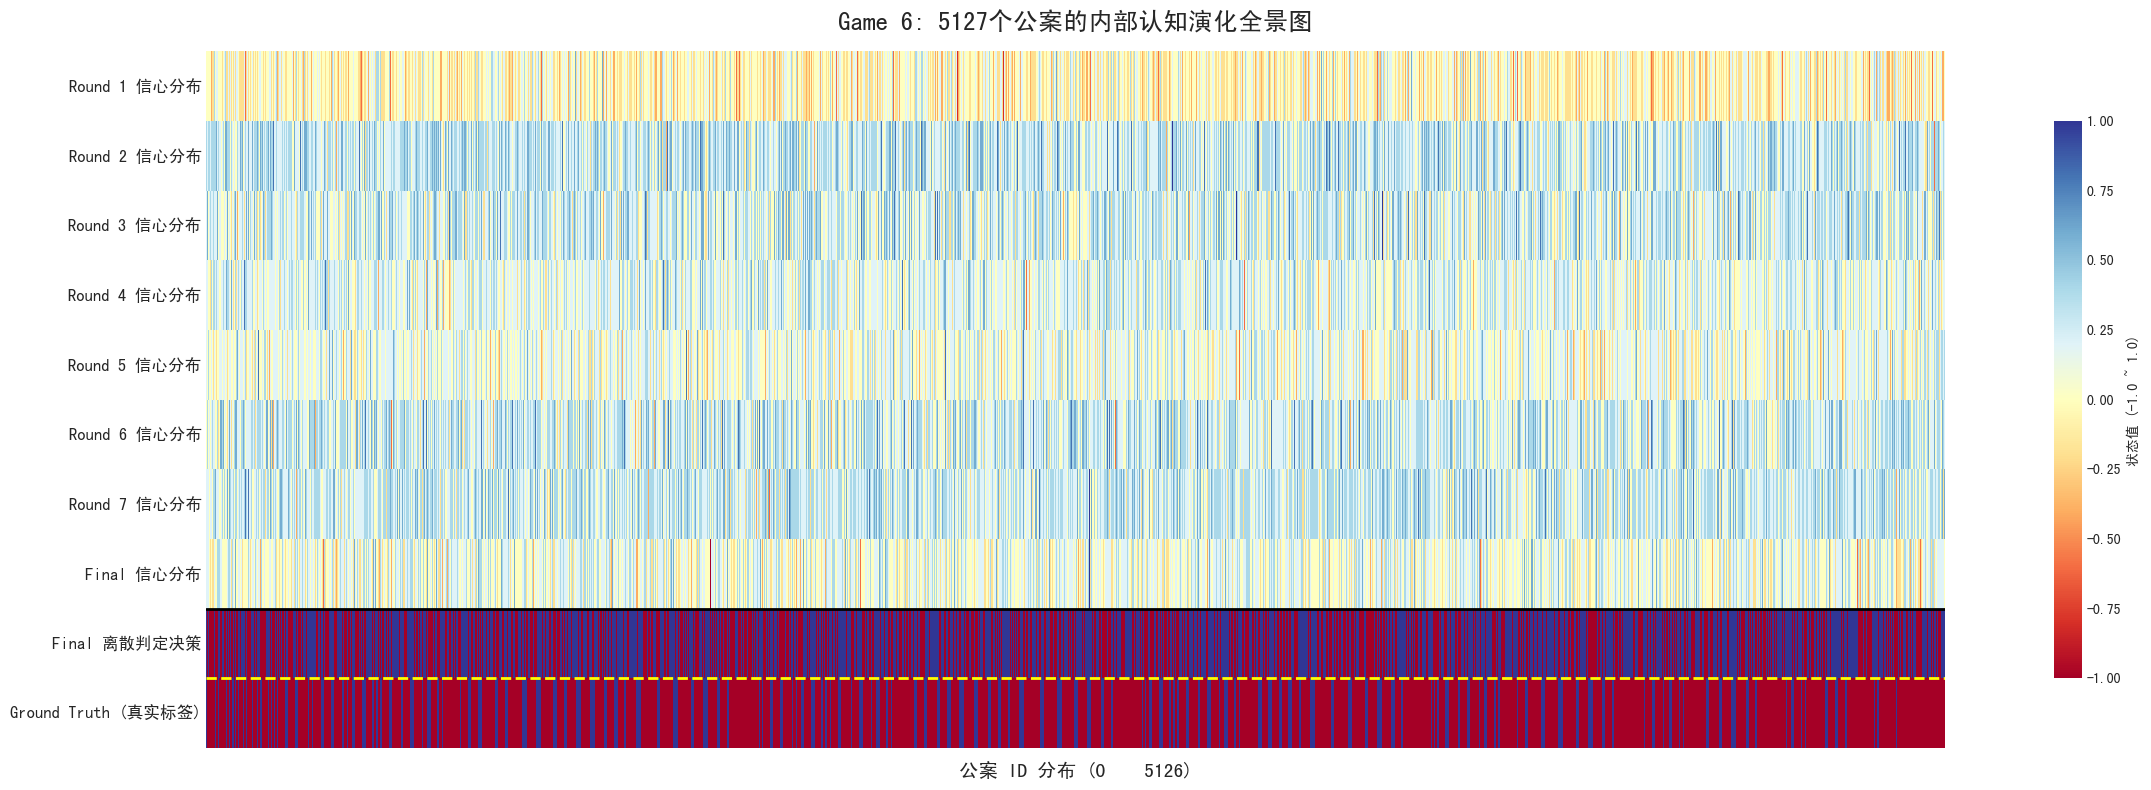

In [5]:
# ========================================
# 全局 5127 个公案的演化全景图 (上帝视角)
# ========================================

# 1. 抽取所有轮次的信心分布
all_confidences = [r["confidence"] for r in rounds_data]

# 2. 抽取最终轮的离散决策
final_decision = rounds_data[-1]["decision"]

# 3. 获取 Ground Truth
ground_truth = gt_vector

# 垂直拼接：前面是各轮的信心，倒数第二行是最终决策，倒数第一行是真实标签
global_heatmap_data = np.vstack([*all_confidences, final_decision, ground_truth])

# 构造 Y 轴标签
yticklabels = [f"Round {i+1} 信心分布" for i in range(len(rounds_data)-1)]
yticklabels.append("Final 信心分布")
yticklabels.append("Final 离散判定决策")
yticklabels.append("Ground Truth (真实标签)")

plt.figure(figsize=(24, 8)) # 极宽的画布，以容纳 5127 个数据点
sns.heatmap(global_heatmap_data, 
            cmap="RdYlBu", 
            center=0, 
            vmin=-1.0, 
            vmax=1.0,
            cbar_kws={'label': '状态值 (-1.0 ~ 1.0)', 'shrink': 0.8},
            yticklabels=yticklabels,
            xticklabels=False) # 横向数据点过多(5127)，直接关掉具体的文字刻度避免黑屏

plt.title(f"Game {GAME_ID}: 5127个公案的内部认知演化全景图", fontsize=18, fontweight='bold', pad=15)
plt.xlabel(f"公案 ID 分布 (0 ⟶ {len(ground_truth)-1})", fontsize=14, labelpad=10)
plt.yticks(rotation=0, fontsize=12)

# 在最后两行之间加一条明显的视觉分割线（突显从“内部认知”到“客观输出”和“真理”的分野）
plt.axhline(len(rounds_data), color='black', linewidth=2, linestyle='-')
plt.axhline(len(rounds_data)+1, color='yellow', linewidth=2, linestyle='--')

plt.tight_layout()
plt.show()

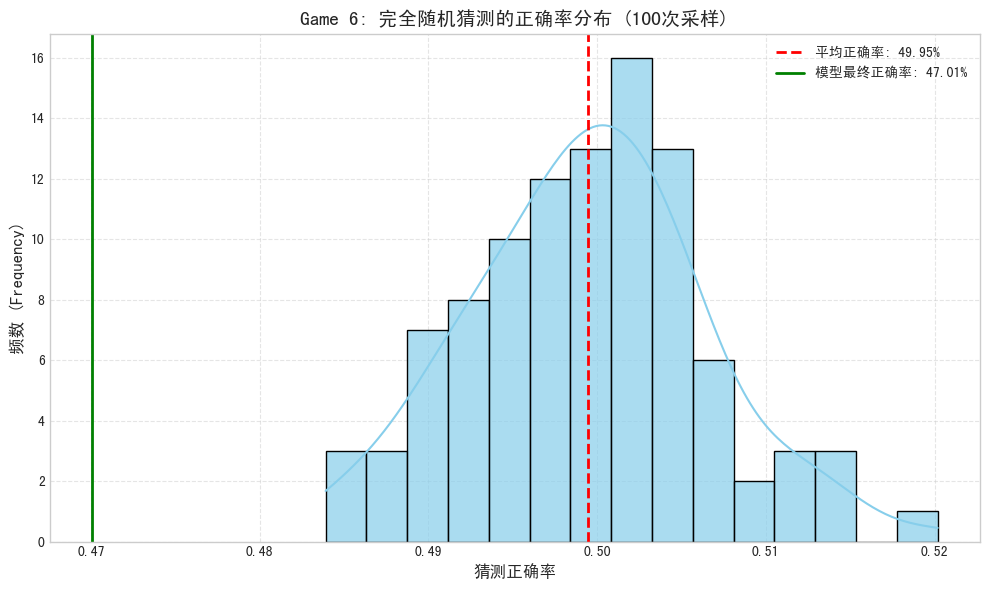

🎲 随机盲猜（100次）的平均正确率: 49.95%


In [6]:
# ========================================
# 随机盲猜基线测试 (Random Baseline)
# ========================================

# 运行 100 次随机盲猜
num_trials = 100
random_accuracies = []

for _ in range(num_trials):
    # 对每个公案完全随机猜测 +1 或 -1
    random_guess = np.random.choice([-1.0, 1.0], size=len(gt_vector))
    acc = np.mean(random_guess == gt_vector)
    random_accuracies.append(acc)

mean_acc = np.mean(random_accuracies)

# 绘制分布直方图
plt.figure(figsize=(10, 6))
sns.histplot(random_accuracies, bins=15, kde=True, color='skyblue', alpha=0.7, edgecolor='black')

# 添加平均值参考线
plt.axvline(mean_acc, color='red', linestyle='dashed', linewidth=2, 
            label=f'平均正确率: {mean_acc*100:.2f}%')

# 若模型最终准确率已定义，也可以画出来对比一下
if 'ultimate_acc' in locals():
    plt.axvline(ultimate_acc, color='green', linestyle='-', linewidth=2, 
                label=f'模型最终正确率: {ultimate_acc*100:.2f}%')

# 美化图表
plt.title(f'Game {GAME_ID}: 完全随机猜测的正确率分布 (100次采样)', fontsize=14, fontweight='bold')
plt.xlabel('猜测正确率', fontsize=12)
plt.ylabel('频数 (Frequency)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

print(f"🎲 随机盲猜（100次）的平均正确率: {mean_acc*100:.2f}%")